##Лабораторная работа №4: Работа с временным рядом (Вариант 5)


In [49]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings
import itertools

warnings.filterwarnings('ignore')

ticker = 'JPM'
data = yf.download(ticker, period='2mo', interval='1h')
df = data[['Close']].dropna()
print(f'\nОбъем выборки: {len(df)} строк.')

[*********************100%***********************]  1 of 1 completed


Объем выборки: 291 строк.


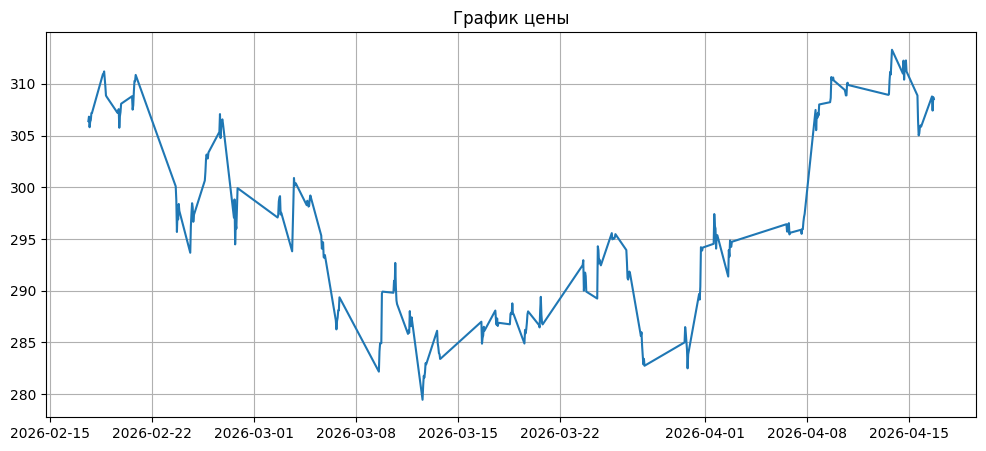

In [50]:
#2. График временного ряда
plt.figure(figsize=(12, 5))
plt.plot(df['Close'])
plt.title(f'График цены')
plt.grid(True)
plt.show()

График показывает, что цены на акции с середины февраля по середину марта демонстрировали устойчивый нисходящий тренд: цена изменилась с 310 к 280 условным единицам. После чего к середене апреля начался восходящий тренд и возвращение к 310 у.е.
Можно заметить, что существует большое количество короткосрочных колебаний цен, которые не подчиняются общему тренду и вызваны внешними факторами.


In [51]:
# 3. Проверка на стационарность через тест Дики-Фуллера
result = adfuller(df['Close'])
print(f'ADF: {result[0]:.4f}, p-value: {result[1]:.4f}')
if result[1] > 0.05:
    print('Ряд не стационарен')
else:
    print('Ряд стационарен')

ADF: -1.5873, p-value: 0.4900
Ряд не стационарен


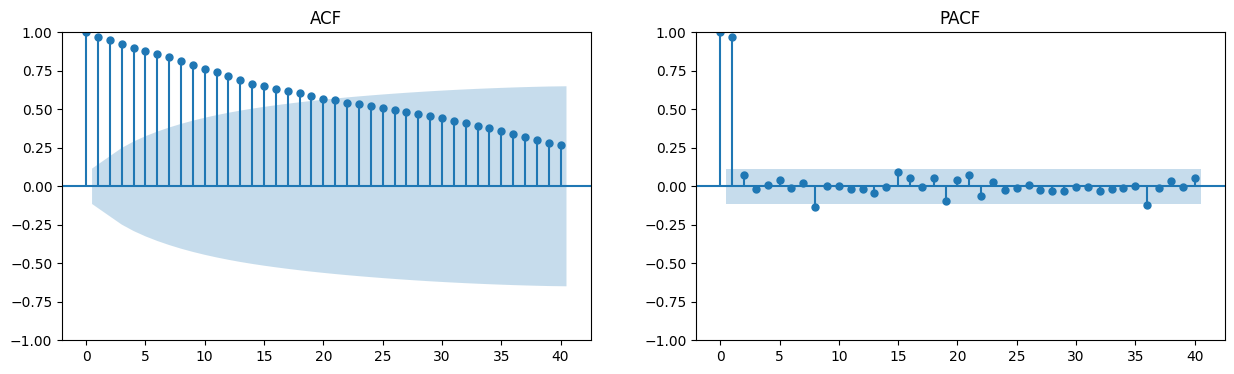

In [52]:
#4. Графики АКФ и ЧАКФ
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df['Close'], lags=40, ax=axes[0])
plot_pacf(df['Close'], lags=40, ax=axes[1])
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.show()

In [53]:
#5-6. Цикл перебора параметров p, d, q
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

p = q = range(0, 3)
d = range(0, 2)
pdq = list(itertools.product(p, d, q))

best_mae = float('inf')
best_order = None

start_time = time.time()
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        res = model.fit()
        if res.mae < best_mae:
            best_mae = res.mae
            best_order = param
    except: continue
end_time = time.time()

print(f'Лучшая модель ARIMA {best_order} (MAE={best_mae:.2f})')
print(f"Время перебора: {end_time - start_time:.2f} сек")

Лучшая модель ARIMA (2, 0, 2) (MAE=1.31)
Время перебора: 4.93 сек


In [54]:
# 7. MAPE
model_final = ARIMA(train, order=best_order)
results_final = model_final.fit()
forecast_test = results_final.forecast(steps=len(test))
mape = mean_absolute_percentage_error(test, forecast_test)
print(f'MAPE на тестовой выборке: {mape:.4%}')

MAPE на тестовой выборке: 3.3584%


In [55]:
# 8. Прогноз
forecast_10 = results_final.get_forecast(steps=10).summary_frame()
display(forecast_10[['mean', 'mean_ci_lower', 'mean_ci_upper']])

JPM,mean,mean_ci_lower,mean_ci_upper
232,296.260154,292.373986,300.146321
233,296.238830,291.043204,301.434456
234,296.222475,290.042274,302.402676
235,296.207712,289.221839,303.193586
236,296.193640,288.521366,303.865914
237,296.180013,287.908918,304.451109
238,296.166760,287.364975,304.968545
239,296.153854,286.876459,305.431250
240,296.141284,286.434041,305.848526
241,296.129037,286.030759,306.227316


In [56]:
#9-10 разделение исходного набора на 3 части и определение лучшей модели по ним
mae_cv = []
parts = np.array_split(df['Close'], 3)

for i, part in enumerate(parts):
    split_idx = int(len(part) * 0.8)
    cv_train = part.iloc[:split_idx]
    cv_test = part.iloc[split_idx:]

    try:
        cv_model = ARIMA(cv_train, order=best_order).fit()
        cv_forecast = cv_model.forecast(steps=len(cv_test))

        err = mean_absolute_error(cv_test, cv_forecast)
        mae_cv.append(err)
        print(f'  Часть {i+1}: MAE = {err:.4%}')
    except Exception as e:
        print(f'  Часть {i+1}: Ошибка при расчете ({e})')

  Часть 1: MAE = 858.1697%
  Часть 2: MAE = 527.5339%
  Часть 3: MAE = 218.5783%
